In [9]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

HOLD_FILE = "/home/haris/results/backtests/720_60_newlabel4_1_3_5_mse7vs3_try2_trade_support7_hold_df.csv"
BARRA_DIR = "/home/haris/project/backtester/barra/barra_from_tonglian"

STYLE_FACTORS = [
    "EARNQLTY",
    "INVSQLTY",
    "ANALSENTI",
    "BETA",
    "STREVRSL",
    "LTREVRSL",
    "BTOP",
    "INDMOM",
    "PROFIT",
    "DIVYILD",
    "EARNVAR",
    "LEVERAGE",
    "EARNYILD",
    "SEASON",
    "LIQUIDTY",
    "GROWTH",
    "SIZE",
    "MOMENTUM",
    "RESVOL",
    "MIDCAP",
]


def load_data():
    hold_df = pd.read_csv(HOLD_FILE)
    hold_df["date"] = hold_df["date"].astype(str)
    hold_df["code"] = hold_df["code"].astype(str).str.zfill(6)
    return hold_df


def run_analysis():
    hold_df = load_data()
    all_dates = sorted(hold_df["date"].unique())
    exposure_list = []

    for date in tqdm(all_dates, desc="Processing daily exposures"):
        barra_path = os.path.join(BARRA_DIR, f"{date}.feather")
        if not os.path.exists(barra_path):
            continue

        barra_df = pd.read_feather(barra_path)
        barra_df["code"] = barra_df["code"].astype(str).str.zfill(6)

        daily_hold = hold_df[hold_df["date"] == date].copy()
        total_amt = daily_hold["amt"].sum()
        if total_amt == 0:
            continue
        daily_hold["weight"] = daily_hold["amt"] / total_amt

        # 合并数据
        merged = pd.merge(daily_hold[["code", "weight"]], barra_df[["code"] + STYLE_FACTORS], on="code", how="inner")
        if merged.empty:
            continue

        # 计算暴露
        port_exposure = merged[STYLE_FACTORS].multiply(merged["weight"], axis=0).sum()
        bench_exposure = barra_df[STYLE_FACTORS].mean()
        diff_exposure = port_exposure - bench_exposure

        res = diff_exposure.to_dict()
        res["date"] = date
        exposure_list.append(res)

    df_diff = pd.DataFrame(exposure_list).set_index("date")
    df_diff.index = pd.to_datetime(df_diff.index)
    return df_diff


def plot_diff_advanced(df_diff):
    df_smooth = df_diff.rolling(window=20).mean()

    plt.figure(figsize=(16, 6))
    cmap = plt.get_cmap("tab20")
    top_diff_factors = df_diff.abs().mean().sort_values(ascending=False).index

    for i, col in enumerate(top_diff_factors):
        plt.plot(df_smooth.index, df_smooth[col], label=col, linewidth=2, color=cmap(i))

    plt.axhline(0, color="black", linestyle="-", linewidth=1.2, alpha=0.7)
    plt.ylabel("Exposure Difference", fontsize=12)
    plt.xlabel("Date", fontsize=12)
    plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", title="Factors")
    plt.title(HOLD_FILE, fontsize=14)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

In [10]:
# 执行分析
diff_results = run_analysis()

Processing daily exposures: 100%|██████████| 1213/1213 [00:49<00:00, 24.75it/s] 


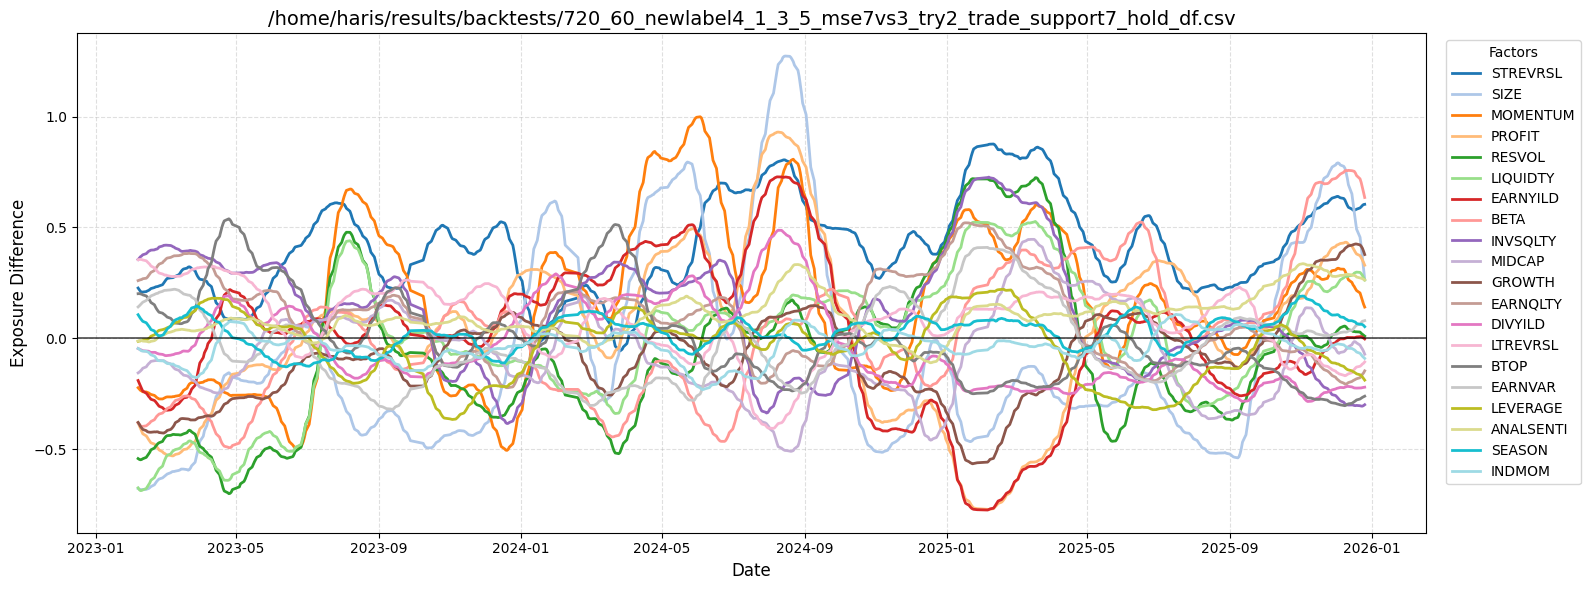

In [11]:
# 画图
plot_diff_advanced(diff_results)